# Relative Dose Plot: MBO CCB vs MBO AIC-144

This notebook compares **MBO foil depth-dose profiles** for **CCB** and **AIC-144**.

Each foil profile is aligned to the **distal 90% falloff point** from its corresponding
**MC wedge simulation** (CCB-to-CCB MC and AIC-144-to-AIC-144 MC).
This preserves the MC-predicted range difference between beams.

Each profile is rescaled so its maximum equals **1.0**.

Color convention:
- **CCB** in **green**
- **AIC-144** in **red**

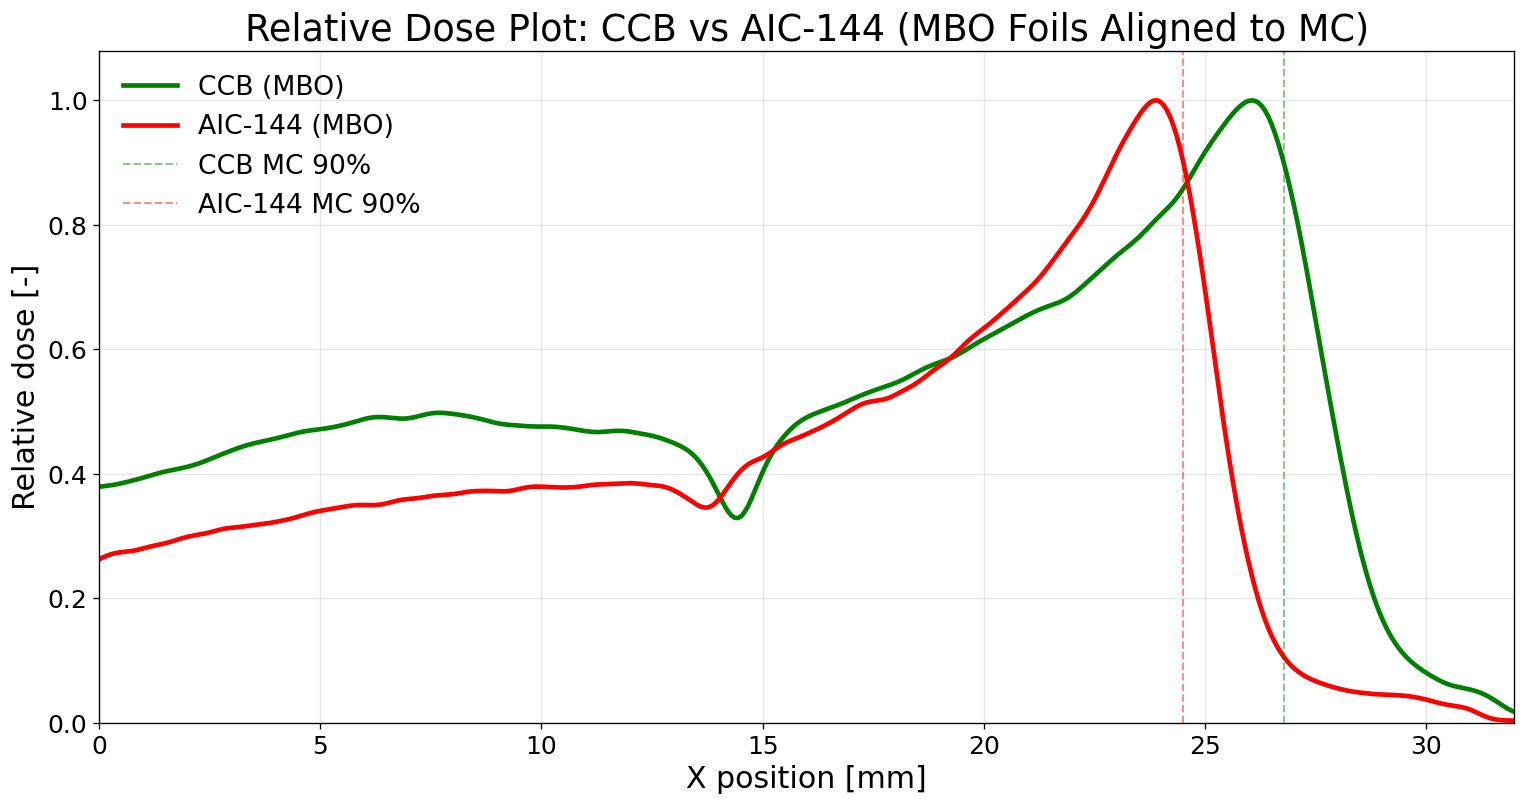

Loaded CCB foil points:      514 from /home/grzanka/workspace/osl_mb_foils/notebooks/pub_something_2026/mbo_foils/mbo_profile_ccb.csv
Loaded AIC-144 foil points:  505 from /home/grzanka/workspace/osl_mb_foils/notebooks/pub_something_2026/mbo_foils/mbo_profile_aic144.csv
Loaded CCB MC points:        640 from /home/grzanka/workspace/osl_mb_foils/notebooks/pub_something_2026/mc/mc_ccb_big.csv
Loaded AIC-144 MC points:    640 from /home/grzanka/workspace/osl_mb_foils/notebooks/pub_something_2026/mc/mc_aic144_big.csv

CCB foil distal 90%:         31.281 mm
CCB MC distal 90%:           26.784 mm -> shift -4.497 mm

AIC-144 foil distal 90%:     29.380 mm
AIC-144 MC distal 90%:       24.515 mm -> shift -4.865 mm

MC range difference (CCB - AIC-144): +2.269 mm


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Resolve repository root from current working directory.
repo_root = Path.cwd()
if not (repo_root / "notebooks" / "pub_something_2026").exists():
    for parent in repo_root.parents:
        if (parent / "notebooks" / "pub_something_2026").exists():
            repo_root = parent
            break

base_root = repo_root / "notebooks" / "pub_something_2026"
foil_root = base_root / "mbo_foils"
mc_root = base_root / "mc"

ccb_file = foil_root / "mbo_profile_ccb.csv"
aic_file = foil_root / "mbo_profile_aic144.csv"
mc_ccb_file = mc_root / "mc_ccb_big.csv"
mc_aic_file = mc_root / "mc_aic144_big.csv"

# Adjustable vertical bump marker bands [mm].
CCB_BUMP_MIN_MM = 13.0
CCB_BUMP_MAX_MM = 15.5
AIC_BUMP_MIN_MM = 12.0
AIC_BUMP_MAX_MM = 14.0
BUMP_BAND_ALPHA = 0.14
BUMP_BAND_YMAX = 0.28  # Draw near the bottom to mark downward bumps.

for f in (ccb_file, aic_file, mc_ccb_file, mc_aic_file):
    if not f.exists():
        raise FileNotFoundError(f"Missing input file: {f}")

ccb = pd.read_csv(ccb_file)
aic = pd.read_csv(aic_file)
mc_ccb = pd.read_csv(mc_ccb_file).rename(columns={"depth": "x_mm", "dose": "dose_Gy"})
mc_aic = pd.read_csv(mc_aic_file).rename(columns={"depth": "x_mm", "dose": "dose_Gy"})

def prepare_profile(df):
    profile = df[["x_mm", "dose_Gy"]].copy().sort_values("x_mm").reset_index(drop=True)
    profile["relative_dose"] = profile["dose_Gy"] / profile["dose_Gy"].max()
    return profile

def distal_falloff_point(profile, level=0.9):
    x = profile["x_mm"].to_numpy()
    y = profile["relative_dose"].to_numpy()

    peak_idx = y.argmax()
    for idx in range(peak_idx + 1, len(y)):
        if y[idx] <= level:
            x0, x1 = x[idx - 1], x[idx]
            y0, y1 = y[idx - 1], y[idx]
            if y1 == y0:
                return x1
            fraction = (level - y0) / (y1 - y0)
            return x0 + fraction * (x1 - x0)

    raise ValueError(f"Could not find distal {level:.0%} falloff point.")

ccb = prepare_profile(ccb)
aic = prepare_profile(aic)
mc_ccb = prepare_profile(mc_ccb)
mc_aic = prepare_profile(mc_aic)

foil_ccb_range_90 = distal_falloff_point(ccb, level=0.9)
foil_aic_range_90 = distal_falloff_point(aic, level=0.9)
mc_ccb_range_90 = distal_falloff_point(mc_ccb, level=0.9)
mc_aic_range_90 = distal_falloff_point(mc_aic, level=0.9)

ccb_shift = mc_ccb_range_90 - foil_ccb_range_90
aic_shift = mc_aic_range_90 - foil_aic_range_90

ccb["x_aligned_mm"] = ccb["x_mm"] + ccb_shift
aic["x_aligned_mm"] = aic["x_mm"] + aic_shift

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 16,
})

fig, ax = plt.subplots(figsize=(13, 7), dpi=120)

ax.axvspan(CCB_BUMP_MIN_MM, CCB_BUMP_MAX_MM, ymin=0.0, ymax=BUMP_BAND_YMAX, color="green", alpha=BUMP_BAND_ALPHA, linewidth=0)
ax.axvspan(AIC_BUMP_MIN_MM, AIC_BUMP_MAX_MM, ymin=0.0, ymax=BUMP_BAND_YMAX, color="red", alpha=BUMP_BAND_ALPHA, linewidth=0)

ax.plot(ccb["x_aligned_mm"], ccb["relative_dose"], color="green", linewidth=2.8, label="CCB (MBO)")
ax.plot(aic["x_aligned_mm"], aic["relative_dose"], color="red", linewidth=2.8, label="AIC-144 (MBO)")

ax.axvline(mc_ccb_range_90, color="green", linestyle="--", linewidth=1.2, alpha=0.45, label="CCB MC 90%")
ax.axvline(mc_aic_range_90, color="red", linestyle="--", linewidth=1.2, alpha=0.45, label="AIC-144 MC 90%")

ax.set_title("Relative Dose Plot: CCB vs AIC-144 (MBO Foils Aligned to MC)")
ax.set_xlabel("X position [mm]")
ax.set_ylabel("Relative dose [-]")
ax.set_xlim(0, 32)
ax.set_ylim(0, 1.08)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

print(f"Loaded CCB foil points:      {len(ccb)} from {ccb_file}")
print(f"Loaded AIC-144 foil points:  {len(aic)} from {aic_file}")
print(f"Loaded CCB MC points:        {len(mc_ccb)} from {mc_ccb_file}")
print(f"Loaded AIC-144 MC points:    {len(mc_aic)} from {mc_aic_file}")
print()
print(f"CCB foil distal 90%:         {foil_ccb_range_90:.3f} mm")
print(f"CCB MC distal 90%:           {mc_ccb_range_90:.3f} mm -> shift {ccb_shift:+.3f} mm")
print()
print(f"AIC-144 foil distal 90%:     {foil_aic_range_90:.3f} mm")
print(f"AIC-144 MC distal 90%:       {mc_aic_range_90:.3f} mm -> shift {aic_shift:+.3f} mm")
print()
print(f"MC range difference (CCB - AIC-144): {mc_ccb_range_90 - mc_aic_range_90:+.3f} mm")